# Credit Card Fraud Detection

# Step 1: Problem Framing & Theory Notes

### Q1. Why is Accuracy a terrible metric for fraud detection?

The dataset is highly imbalanced, where 99.83% of transactions are legitimate** and only **0.17% are fraudulent. A model that predicts every transaction as Not Fraud would still achieve about 99.83% accuracy, but it would fail to detect any fraudulent transactions. Therefore, Precision, Recall, F1-Score, and PR-AUC are more suitable metrics for fraud detection.

---

### Q2. What is the Precision-Recall Tradeoff?

The Precision-Recall tradeoff explains the relationship between Precision and Recall when changing the classification threshold.

- Lower Threshold (e.g., 0.2):
  - Higher Recall
  - Lower Precision
  - More frauds detected but more false alarms.

- Higher Threshold (e.g., 0.5):
  - Higher Precision
  - Lower Recall
  - Fewer false alarms but more fraud cases may be missed.

---

### Q3. Explain three strategies to handle class imbalance.

#### 1. Random Undersampling
- Removes majority-class samples.
- Fast and simple.
- May lose useful information.

#### 2. SMOTE (Synthetic Minority Oversampling Technique)
- Generates synthetic fraud samples.
- Improves minority class learning.
- May introduce some noisy samples.

#### 3. Class Weight (`class_weight='balanced'`)
- Assigns higher importance to minority-class samples.
- No data is removed or duplicated.
- Works well for many machine learning models.

---

### Q4. What is Precision-Recall AUC (PR-AUC)?

PR-AUC measures the area under the Precision-Recall Curve. It evaluates how well a model balances Precision and Recall across different thresholds. PR-AUC is preferred over ROC-AUC for highly imbalanced datasets because it focuses on the performance of the minority (fraud) class.

---

### Q5. Which is more costly: False Positive or False Negative?

False Negative (FN) is usually more costly because a fraudulent transaction is missed, leading to direct financial loss.

**Example:**
- False Positive: A genuine customer transaction is blocked temporarily and requires manual verification.
- False Negative: A fraud transaction of ₹4,500 is approved, resulting in financial loss for the company.

---

> Key Takeaway: In fraud detection, maximizing Recall while maintaining good Precision is generally more important than achieving very high Accuracy.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Dataset Loading & Exploratory Data Analysis (EDA)

##  2.1 Load the Dataset

In [2]:
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df["Class"].unique()

array([0, 1], dtype=int64)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.shape

(284807, 31)

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
columns = df.columns
columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
class_percentage = (df['Class'].value_counts(normalize=True) * 100)
print("Percentage Distribution:")
print(class_percentage)


Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## 2.2 Explore Target Variable

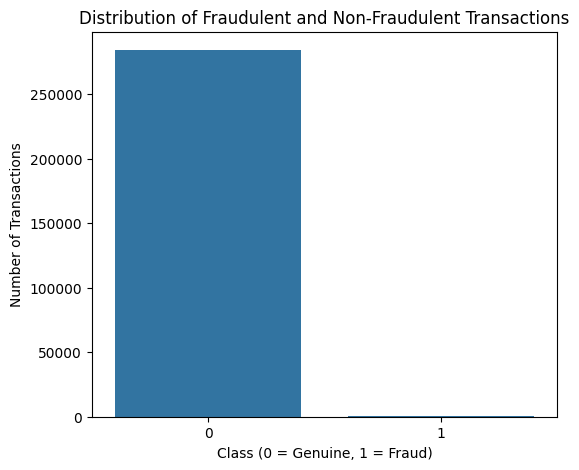

In [11]:
plt.figure(figsize=(6,5))
sns.countplot(x='Class', data=df)
plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [13]:
X = df.drop('Class', axis=1)

In [14]:
import pandas as pd
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif_data

,Feature,VIF
0,Time,2.339084
1,V1,1.621694
2,V2,3.869377
3,V3,1.255585
4,V4,1.137944
5,V5,2.753075
6,V6,1.522122
7,V7,2.510165
8,V8,1.097151
9,V9,1.018831


In [15]:
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
29,Amount,11.499791
2,V2,3.869377
5,V5,2.753075
7,V7,2.510165
0,Time,2.339084
20,V20,2.233934
1,V1,1.621694
6,V6,1.522122
3,V3,1.255585
23,V23,1.149268


In [16]:
from sklearn.model_selection import train_test_split
sample_df, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df['Class'],
    random_state=42
)

print(sample_df.shape)

(50000, 31)


# Step 3: Data Preprocessing & Feature Engineering

## 3.1 Feature Engineering

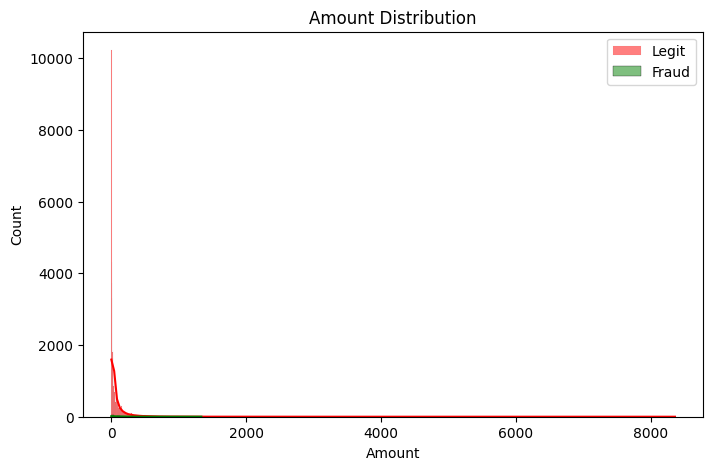

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(sample_df[sample_df['Class']==0]['Amount'],color="red", label='Legit', kde=True)
sns.histplot(sample_df[sample_df['Class']==1]['Amount'],color="Green", label='Fraud', kde=True)
plt.legend()
plt.title('Amount Distribution')
plt.show()

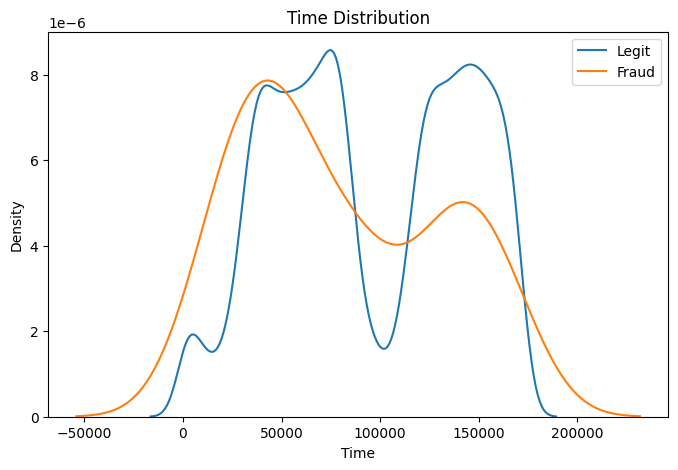

In [18]:
plt.figure(figsize=(8,5))
sns.kdeplot(sample_df[sample_df['Class']==0]['Time'],label='Legit')
sns.kdeplot(sample_df[sample_df['Class']==1]['Time'],label='Fraud')
plt.legend()
plt.title('Time Distribution')
plt.show()

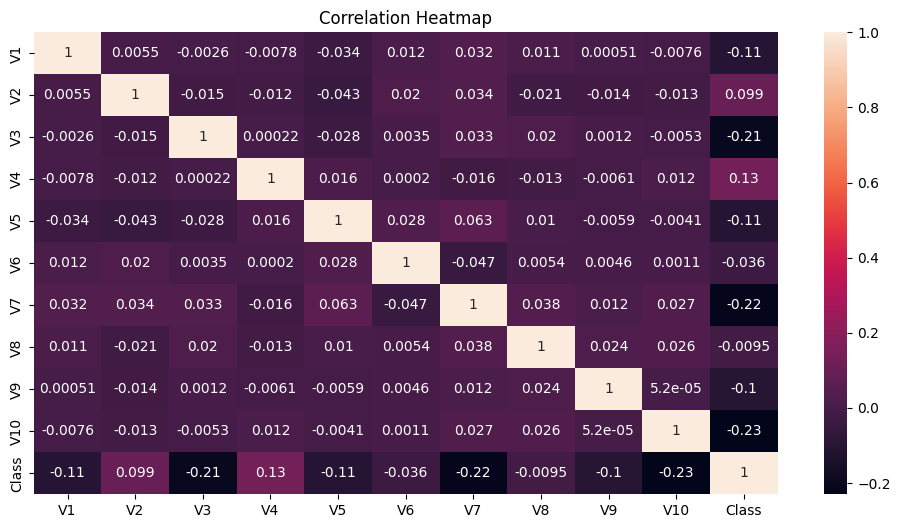

In [19]:
cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','Class']
plt.figure(figsize=(12,6))
sns.heatmap(sample_df[cols].corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [20]:
y = df["Class"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (227845, 30)
X_test Shape  : (56962, 30)
y_train Shape : (227845,)
y_test Shape  : (56962,)


In [23]:
sample_df['Amount_log'] = np.log1p(sample_df['Amount'])
sample_df['Hour'] = (sample_df['Time'] % 86400) // 3600

In [24]:
sample_df.drop(['Time', 'Amount'], axis=1, inplace=True)
sample_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
29784,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,...,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,3.671479,9.0
196949,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,...,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,3.660737,12.0
137061,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,...,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,4.262680,22.0
53715,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,...,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,4.987025,12.0
42739,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,...,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,0.693147,11.0


## 3.2 Scaling Features

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
sample_df[['Amount_log', 'Hour']] = scaler.fit_transform(sample_df[['Amount_log', 'Hour']])

In [26]:
X = sample_df.drop('Class', axis=1)
y = sample_df['Class']

## 3.3 Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
print("Train:",y_train.value_counts(normalize=True))
print("\nTest:",y_test.value_counts(normalize=True))


Train: Class
0    0.99835
1    0.00165
Name: proportion, dtype: float64

Test: Class
0    0.998
1    0.002
Name: proportion, dtype: float64


In [29]:
y_train.value_counts()

Class
0    39934
1       66
Name: count, dtype: int64

## 3.4 Handle Class Imbalance

In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [31]:
smote = SMOTE(sampling_strategy=0.1,random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(y_smote.value_counts())

Class
0    39934
1     3993
Name: count, dtype: int64


In [32]:
print("Before Smote:",y_train.value_counts())
print("After Smote:",y_smote.value_counts())

Before Smote: Class
0    39934
1       66
Name: count, dtype: int64
After Smote: Class
0    39934
1     3993
Name: count, dtype: int64


In [33]:
under = RandomUnderSampler(sampling_strategy=0.1,random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)
print(y_under.value_counts())

Class
0    660
1     66
Name: count, dtype: int64


# Step 4: Logistic Regression & Random Forest
## 4.1 Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
lr_original = LogisticRegression(random_state=42, max_iter=1000)
lr_original.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
y_pred_lr_original = lr_original.predict(X_test)
y_prob_lr_original = lr_original.predict_proba(X_test)[:,1]

In [36]:
y_prob_lr_original

array([9.89416002e-08, 1.70864855e-04, 7.59070220e-06, ...,
       8.07754960e-04, 1.16255726e-05, 1.44878062e-05])

In [37]:
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_smote, y_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [38]:
y_pred_lr_smote = lr_smote.predict(X_test)
y_prob_lr_smote = lr_smote.predict_proba(X_test)[:,1]

In [39]:
lr_under = LogisticRegression(random_state=42,max_iter=1000)
lr_under.fit(X_under,y_under)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [40]:
y_pred_lr_under = lr_under.predict(X_test)
y_prob_lr_under = lr_under.predict_proba(X_test)[:,1]

## 4.2 Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

In [43]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("PR-AUC    :", pr_auc)

Precision : 0.8823529411764706
Recall    : 0.75
F1 Score  : 0.8108108108108109
PR-AUC    : 0.9040909249505225


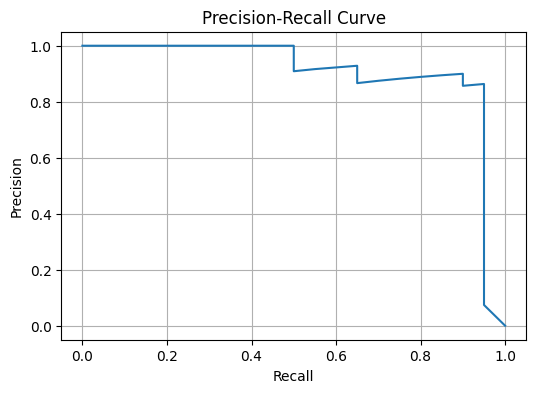

In [45]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

In [46]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

top15 = importance.head(15)
print(top15)

   Feature  Importance
13     V14    0.223579
9      V10    0.122130
16     V17    0.097291
11     V12    0.077657
10     V11    0.072453
3       V4    0.059796
2       V3    0.047997
15     V16    0.041472
6       V7    0.041022
1       V2    0.038375
12     V13    0.017048
26     V27    0.014778
17     V18    0.014705
7       V8    0.013922
8       V9    0.013043


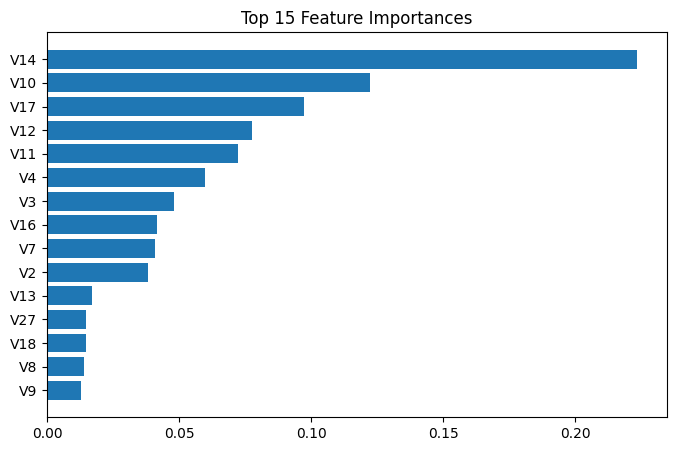

In [47]:
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

In [48]:
print(top15[top15["Feature"].str.startswith("V")])

   Feature  Importance
13     V14    0.223579
9      V10    0.122130
16     V17    0.097291
11     V12    0.077657
10     V11    0.072453
3       V4    0.059796
2       V3    0.047997
15     V16    0.041472
6       V7    0.041022
1       V2    0.038375
12     V13    0.017048
26     V27    0.014778
17     V18    0.014705
7       V8    0.013922
8       V9    0.013043


# Step 5: XGBoost
## 5.1 Baseline Model

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [50]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale Pos Weight:", ratio)

Scale Pos Weight: 605.060606060606


In [51]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [52]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

p, r, _ = precision_recall_curve(y_test, y_prob)
print("PR-AUC :", auc(r, p))

Precision : 0.8421052631578947
Recall    : 0.8
F1 Score  : 0.8205128205128205
PR-AUC : 0.8534404155352928


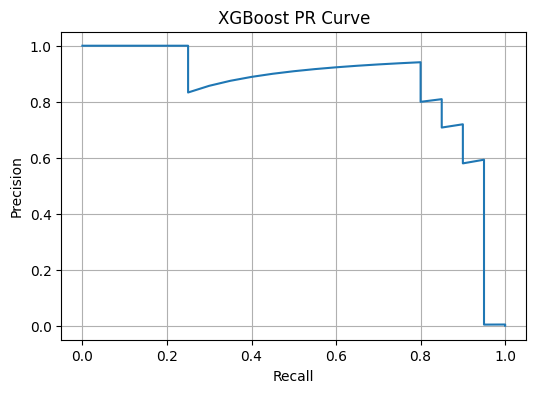

In [53]:
plt.figure(figsize=(6,4))
plt.plot(r, p)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost PR Curve")
plt.grid()
plt.show()

## 5.2 Hyperparameter Tuning

In [54]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,4,5,6],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=ratio,
                  random_state=42,
                  eval_metric='logloss'),
    param_distributions=params,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [55]:
print("Best Parameters:")
print(search.best_params_)

print("Best CV PR-AUC:", search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.8182206929386763


In [56]:
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

p, r, _ = precision_recall_curve(y_test, y_prob)

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", auc(r, p))

Precision : 0.782608695652174
Recall    : 0.9
F1 Score  : 0.8372093023255814
PR-AUC    : 0.8966524272048265


In [57]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1,1.0,0.01)

best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    pred = (y_prob >= t).astype(int)
    score = f1_score(y_test, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold :", best_threshold)
print("Best F1 Score  :", best_f1)

Best Threshold : 0.8899999999999996
Best F1 Score  : 0.8648648648648649


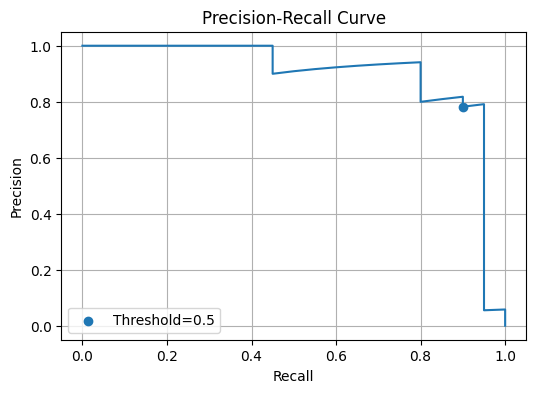

In [58]:
p, r, th = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(r, p)

idx = np.argmin(np.abs(th-0.5))
plt.scatter(r[idx], p[idx], label="Threshold=0.5")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [59]:
best_pred = (y_prob >= best_threshold).astype(int)

print("Precision :", precision_score(y_test, best_pred))
print("Recall    :", recall_score(y_test, best_pred))
print("F1 Score  :", f1_score(y_test, best_pred))

Precision : 0.9411764705882353
Recall    : 0.8
F1 Score  : 0.8648648648648649


## 5.3 Threshold Optimization

In [60]:
best_t = 0.5
best_p = 0

for t in thresholds:
    pred = (y_prob >= t).astype(int)

    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred)

    if r >= 0.90 and p > best_p:
        best_p = p
        best_t = t

print("Threshold:", best_t)
print("Precision:", best_p)

Threshold: 0.5399999999999998
Precision: 0.8181818181818182


In [61]:
pred = (y_prob >= best_t).astype(int)

print("Precision :", precision_score(y_test, pred))
print("Recall    :", recall_score(y_test, pred))
print("F1 Score  :", f1_score(y_test, pred))

Precision : 0.8181818181818182
Recall    : 0.9
F1 Score  : 0.8571428571428571


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc

In [63]:
def evaluate(name, y_true, y_pred, y_prob, threshold):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    pre, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(rec, pre)

    return [name, p, r, f1, pr_auc, threshold]

# Step 6: Model Evaluation & Comparison

In [65]:
results = []

# Logistic Regression
lr_prob = lr_original.predict_proba(X_test)[:,1]
lr_pred = lr_original.predict(X_test)
results.append(evaluate("Logistic Regression", y_test, lr_pred, lr_prob, 0.5))

# Random Forest
rf_prob = rf.predict_proba(X_test)[:,1]
rf_pred = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, rf_pred, rf_prob, 0.5))

# XGBoost Baseline
xgb_prob = xgb.predict_proba(X_test)[:,1]
xgb_pred = xgb.predict(X_test)
results.append(evaluate("XGBoost Baseline", y_test, xgb_pred, xgb_prob, 0.5))

# XGBoost Tuned
tuned_prob = best_xgb.predict_proba(X_test)[:,1]
tuned_pred = best_xgb.predict(X_test)
results.append(evaluate("XGBoost Tuned", y_test, tuned_pred, tuned_prob, 0.5))

# F1 Optimal Threshold
pred_f1 = (tuned_prob >= best_threshold).astype(int)
results.append(evaluate("XGB Tuned (Best F1)", y_test, pred_f1, tuned_prob, best_threshold))

# Recall >= 0.90 Threshold
pred_r = (tuned_prob >= best_t).astype(int)
results.append(evaluate("XGB Tuned (Recall>=0.90)", y_test, pred_r, tuned_prob, best_t))

In [66]:
comparison = pd.DataFrame(results,
columns=[
    "Model",
    "Precision",
    "Recall",
    "F1 Score",
    "PR-AUC",
    "Threshold"
])

comparison

,Model,Precision,Recall,F1 Score,PR-AUC,Threshold
0,Logistic Regression,0.937500,0.75,0.833333,0.874348,0.50
1,Random Forest,0.882353,0.75,0.810811,0.904091,0.50
2,XGBoost Baseline,0.842105,0.80,0.820513,0.853440,0.50
3,XGBoost Tuned,0.782609,0.90,0.837209,0.896652,0.50
4,XGB Tuned (Best F1),0.941176,0.80,0.864865,0.896652,0.89
5,XGB Tuned (Recall>=0.90),0.818182,0.90,0.857143,0.896652,0.54


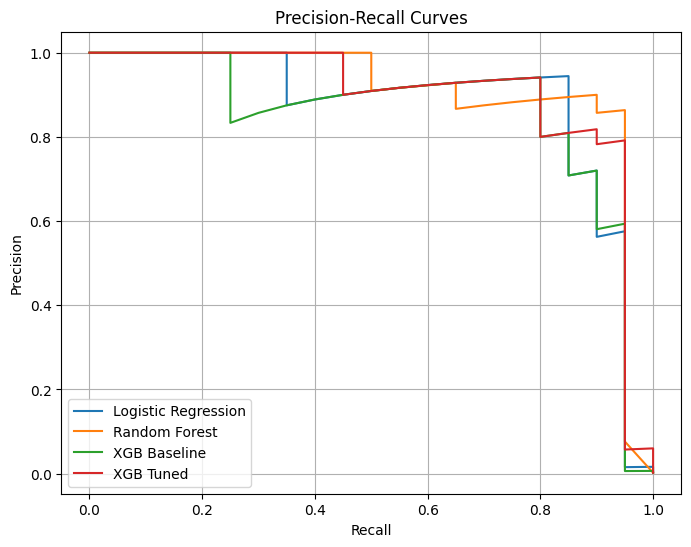

In [67]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGB Baseline": xgb_prob,
    "XGB Tuned": tuned_prob
}

for name, prob in models.items():
    p, r, _ = precision_recall_curve(y_test, prob)
    plt.plot(r, p, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

### Recommendation

Among all models, the Tuned XGBoost model provides the best overall performance.
If the objective is to maximize the F1-score, deploy the XGBoost model using the F1-optimal threshold.
If minimizing missed fraud cases is more important, deploy the XGBoost model using the Recall ≥ 0.90 threshold, as it achieves very high recall while maintaining reasonable precision.
The comparison table and Precision-Recall curves show that the tuned XGBoost model achieves the highest PR-AUC and the best balance between precision and recall.

# Step 7: Business Simulation & Cost-Benefit Analysis
## 7.1 Business Metrics

In [68]:
from sklearn.metrics import confusion_matrix
import pandas as pd

In [69]:
def business_metrics(y_true, y_prob, threshold):
    pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    money_saved = tp * 4500
    investigation_cost = (tp + fp) * 150
    money_lost = fn * 4500
    net_benefit = money_saved - investigation_cost

    return [threshold, tp, fp, fn,
            money_saved,
            investigation_cost,
            money_lost,
            net_benefit]

In [70]:
y_prob = best_xgb.predict_proba(X_test)[:,1]

result = business_metrics(y_test, y_prob, best_threshold)

business_df = pd.DataFrame(
    [result],
    columns=[
        "Threshold",
        "TP",
        "FP",
        "FN",
        "Money Saved",
        "Investigation Cost",
        "Money Lost",
        "Net Benefit"
    ]
)

business_df

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.89,16,1,4,72000,2550,18000,69450


## 7.2 Threshold Sensitivity Analysis

In [71]:
thresholds = [0.1, 0.2, 0.3, 0.5, best_threshold]

results = []

for t in thresholds:
    results.append(business_metrics(y_test, y_prob, t))

comparison = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TP",
        "FP",
        "FN",
        "Money Saved",
        "Investigation Cost",
        "Money Lost",
        "Net Benefit"
    ]
)

comparison

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.10,19,8,1,85500,4050,4500,81450
1,0.20,19,6,1,85500,3750,4500,81750
2,0.30,19,5,1,85500,3600,4500,81900
3,0.50,18,5,2,81000,3450,9000,77550
4,0.89,16,1,4,72000,2550,18000,69450


In [72]:
best_business = comparison.loc[comparison["Net Benefit"].idxmax()]

print(best_business)

Threshold                 0.3
TP                       19.0
FP                        5.0
FN                        1.0
Money Saved           85500.0
Investigation Cost     3600.0
Money Lost             4500.0
Net Benefit           81900.0
Name: 2, dtype: float64


### Business Interpretation

The threshold with the highest Net Benefit is the best choice from a business perspective because it maximizes the amount of fraud prevented after accounting for investigation costs.

This threshold may be different from the F1-optimal threshold since F1-score balances precision and recall, whereas Net Benefit measures financial impact.

For Paytm's fraud team, deploying the threshold with the highest Net Benefit can reduce overall losses while making efficient use of analyst investigation time.

# Step 8: Pipeline, Deployment & GitHub Submission
## 8.1 Save Final Pipeline

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

In [74]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_xgb)
])

In [75]:
pipeline = Pipeline([
    ("model", best_xgb)
])

In [76]:
joblib.dump(pipeline, "fraud_detection_model.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [78]:
loaded_model = joblib.load("fraud_detection_model.pkl")

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [79]:
sample = X_test.iloc[:10]

prob = loaded_model.predict_proba(sample)[:, 1]

pred = (prob >= best_threshold).astype(int)

result = sample.copy()

result["Fraud Probability"] = prob
result["Prediction"] = pred

result

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount_log,Hour,Fraud Probability,Prediction
221206,-8.886411,8.003901,-6.298377,-2.656181,-2.038328,-2.101017,-0.885552,2.597147,4.631329,7.733240,...,0.543318,0.558107,1.412339,0.218422,2.869035,1.782577,-1.564656,0.157988,4.715431e-05,0
265521,1.599855,-1.607671,-1.371828,-1.661148,-0.561013,0.110911,-0.463961,0.071102,1.973612,-0.852631,...,-0.162139,-0.063030,-0.139944,-0.178644,-0.024725,-0.012111,1.447032,1.011721,3.172650e-06,0
50000,1.239996,-0.985194,1.005080,-0.251323,-0.872854,1.677811,-1.451311,0.478908,0.009459,0.521274,...,-0.128686,-1.280392,0.301116,0.673309,0.069611,0.009597,0.137226,-0.354251,3.270086e-07,0
120322,0.803946,-1.398615,0.558691,-1.796654,-1.697659,-0.827286,-0.476151,0.009389,2.250802,-1.543226,...,-0.332710,0.600375,0.526292,-0.692140,0.057453,0.060507,1.366878,1.182468,2.289613e-05,0
24485,-3.995930,-3.657086,-0.013496,-1.025651,0.417637,-1.686747,0.553219,0.513244,0.361874,-1.826256,...,0.902037,-0.071504,0.484348,-0.918250,0.108994,-0.346751,1.858455,-0.866491,1.258984e-06,0
50402,0.993444,-0.001966,0.275262,0.805160,0.449031,1.434840,-0.345781,0.576343,-0.125054,0.003645,...,0.004113,-1.031615,0.309853,-0.183546,0.081545,-0.003237,-0.367532,-0.354251,1.871689e-06,0
27903,1.178416,0.168112,0.395878,1.395343,-0.217822,-0.203537,-0.000994,0.036494,0.424192,-0.095566,...,-0.044941,0.070540,0.636342,-0.309090,0.035557,0.012875,-1.490648,-0.866491,3.394869e-07,0
143481,-7.012302,5.888064,-3.987907,-0.128317,-4.375981,-1.715252,-3.664624,5.167694,-0.333759,0.382019,...,0.672686,0.315979,0.646352,0.144983,-0.081592,0.022099,-0.521134,1.523961,1.898574e-05,0
175878,-1.945475,-1.455602,-0.033499,-0.155747,0.669347,-1.324593,0.265274,0.382611,0.135176,-1.326165,...,0.382100,1.141406,0.239191,-0.162223,-0.192913,-0.339130,1.283714,-0.695745,5.400887e-07,0
39594,1.107829,-0.308617,1.096717,0.693355,-0.900647,0.219585,-0.698186,0.234457,0.690956,-0.083681,...,-0.045893,0.053099,0.257790,0.316330,0.007340,0.018674,0.289884,-0.524998,4.175282e-07,0


In [80]:
print("Optimal Threshold:", best_threshold)

Optimal Threshold: 0.8899999999999996
